# [1교시]

1. LSTM이 왜 긴 문장을 잘 못 기억하는가
2. Attention이 어떻게 그 문제를 해결하는가
3. Query, Key, Value를 어떻게 직관적으로 이해할 수 있는가
4. Self-Attention이 왜 강력한가
5. Transformer가 왜 Attention을 중심으로 설계되었는가

![이미지 설명](./pictures01.jpg)

## 1. LSTM의 한계: 긴 문장을 끝까지 기억하기 어렵다

LSTM은 RNN의 약점을 보완한 모델이지만, 문장이 길어지면 여전히 앞부분 정보가 뒤까지 온전히 전달되기 어렵다. 마치 긴 회의 내용을 마지막 사람에게 전달하는데, 중간에 몇 명만 거치면 처음 이야기가 흐려지는 것과 같다.

LSTM은 gate를 통해 정보를 조절하지만, 모든 단어를 같은 비중으로 저장할 수는 없다. 결국 오래된 정보는 점점 약해지고, 중요한 단서가 사라질 수 있다.

### 왜 문제가 되는가

예를 들어 한국어 문장:

> "어제 늦게 도착했지만, 오랜 기다림 끝에 본 영화는 정말 감동적이었다."

이 문장에서 감정을 결정하는 핵심은 뒤쪽의 "감동적이었다"이다. 하지만 앞의 "늦게 도착했지만" 같은 정보와 섞이면서, LSTM은 전체 감정을 안정적으로 잡기 어려울 수 있다.

### 수식으로 보는 느낌

LSTM은 보통 다음과 같이 상태를 갱신한다.

$$
i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i)
$$

$$
f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)
$$

$$
o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o)
$$

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

여기서 중요한 점은, 과거 정보가 $c_{t-1}$에 남더라도 게이트를 거치며 점점 희석될 수 있다는 것이다. 즉, “무엇이 정말 중요한지”를 매 시점 자동으로 강하게 선택해 주지는 못한다.

### 예제 문장

- "이 영화는 초반은 지루했지만, 결말이 아주 훌륭했다."

이 문장에서 분류의 핵심은 "결말이 아주 훌륭했다"이다. 긴 문장일수록 뒷부분의 중요한 단어를 안정적으로 잡아야 한다.

## 2. 긴 문장 기억 문제: 모든 단어를 똑같이 보면 안 된다

### 핵심 직관

사람도 긴 문장을 읽을 때 모든 단어를 동일하게 기억하지 않는다. 중요한 단어에 밑줄을 긋듯, 모델도 핵심 단어에 더 높은 주의를 줘야 한다.

예를 들어 다음 문장에서 감정을 판단할 때:

> "음식은 평범했지만, 직원의 친절함 덕분에 기분 좋게 식사했다."

"직원의 친절함", "기분 좋게"는 감정 판단에 매우 중요하다. 반면 "음식은 평범했지만"은 보조 정보에 가깝다.

### Attention이 필요한 이유

Attention은 문장 전체를 한 덩어리로 압축하지 않고, 필요한 순간마다 "어떤 단어를 더 볼지" 선택하게 만든다. 그래서 긴 문장에서도 중요한 정보가 사라질 가능성이 줄어든다.

### 비유

도서관에서 책 한 권을 찾을 때, 모든 페이지를 처음부터 끝까지 똑같이 외우지 않는다. 색인이나 목차를 보고 필요한 부분으로 바로 간다. Attention은 바로 그 "색인" 같은 역할을 한다.

### 예제 문장

- "수업은 길었지만 설명이 명확해서 이해하기 쉬웠다."

이 문장에서 핵심은 "설명이 명확해서 이해하기 쉬웠다"이다. 긴 앞부분보다 뒤의 판단 단어가 더 중요하다.

## 3. Attention의 핵심: 중요한 단어에 집중한다

### 핵심 직관

Attention은 말 그대로 "주의를 주는 메커니즘"이다. 모델이 문장을 볼 때 모든 단어에 같은 힘을 쓰지 않고, 현재 필요한 정보에 더 많은 비중을 준다.

예를 들어 번역할 때 영어 문장 "I ate an apple"을 한국어로 옮기면, "apple"이라는 단어를 볼 때 모델은 이전 문장 전체가 아니라 관련 단어에 더 강하게 반응해야 한다.

### 아주 쉬운 비유

친구가 "어제 본 영화는 재미없었지만 음악은 좋았어"라고 말하면, 감정을 요약할 때 사람은 "재미없었지만"과 "좋았어"를 먼저 본다. Attention도 이처럼 문장 속에서 결정적인 단어를 골라 본다.

### 기본 수식

Attention은 일반적으로 다음처럼 표현한다.

$$
Attention(Q, K, V) = softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

여기서 중요한 것은 수식 자체보다 역할이다.

- $Q$는 지금 무엇을 찾고 있는지
- $K$는 각 단어가 어떤 특징을 가지고 있는지
- $V$는 실제로 가져올 정보

### 예제 문장

- "그 카페는 분위기는 좋았지만 커피 맛은 아쉬웠다."

이 문장에서 감정 판단에는 "아쉬웠다"가 더 중요하므로 Attention은 그 단어에 더 높은 가중치를 줄 수 있다.

## 4. Query, Key, Value 직관: 찾기, 비교하기, 가져오기

### 직관적 정의

이 세 단어를 검색 시스템으로 이해하면 쉽다.

- Query: 내가 지금 찾고 싶은 것
- Key: 각 정보가 가진 표지판
- Value: 실제로 가져갈 내용

### 비유 1: 도서관

도서관에서 "한국어 문법" 책을 찾는다고 하자.

- Query는 "한국어 문법"을 찾는 내 요청
- Key는 각 책 등에 붙은 제목, 주제, 분류 번호
- Value는 책의 실제 내용

제목(Key)이 Query와 잘 맞는 책을 찾으면, 그 책의 내용(Value)을 읽는다.

### 비유 2: 식당 추천

"매운 음식"을 찾는다면:

- Query: 매운 음식을 먹고 싶다
- Key: 각 메뉴의 특징 태그
- Value: 실제 메뉴 정보

태그가 잘 맞는 메뉴를 더 크게 참고하게 된다.

### 수식으로 보는 점수 계산

Query와 Key의 유사도는 보통 내적으로 계산한다.

$$
score(q, k_i) = q \cdot k_i
$$

점수를 모두 계산한 뒤 softmax로 확률처럼 바꾼다.

$$
\alpha_i = \frac{e^{score(q, k_i)}}{\sum_j e^{score(q, k_j)}}
$$

마지막으로 Value를 가중합한다.

$$
output = \sum_i \alpha_i v_i
$$

즉, 중요한 정보일수록 $\alpha_i$가 크고, 결과에 더 많이 반영된다.

### 예제 문장

- "영화는 길었지만 결말이 강렬해서 기억에 남았다."

Query가 "기억에 남은 이유"라면 Key 중 "결말이 강렬해서"가 가장 높은 점수를 받을 가능성이 크다.

## 5. Attention 수식: 어렵게 보이지만 결국은 가중 평균이다

### 핵심 직관

Attention의 본질은 복잡한 공식을 가진 특별한 마법이 아니라, "중요한 것에 더 큰 비중을 두는 가중 평균"이다.

예를 들어 세 사람의 의견을 반영할 때, 가장 경험 많은 사람 의견에 더 큰 가중치를 줄 수 있다. Attention도 문장 속 단어들에게 그런 방식으로 비중을 준다.

### 대표 수식

$$
Attention(Q, K, V) = softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

이 수식은 세 단계로 읽으면 쉽다.

1. Query와 Key의 유사도를 계산한다.
2. softmax로 중요도를 정규화한다.
3. Value를 중요도에 따라 섞는다.

### 왜 $\sqrt{d_k}$로 나누는가

차원이 커질수록 내적 값이 너무 커질 수 있다. 그러면 softmax가 한쪽으로 쏠려 학습이 불안정해진다. 그래서 $\sqrt{d_k}$로 나누어 점수를 적당한 크기로 만든다.

### 예제 문장

- "오늘은 비가 왔지만 산책은 즐거웠다."

이 문장에서는 "즐거웠다"가 최종 감정에 더 큰 영향을 주며, Attention은 그쪽에 더 큰 비중을 줄 수 있다.

## 6. Self-Attention: 문장 안의 단어들이 서로를 바라본다

### 핵심 직관

Self-Attention은 말 그대로 "자기 자신 안에서 서로를 참고하는 Attention"이다. 문장 안의 각 단어가 다른 단어들과 관계를 맺는다.

예를 들어:

> "그 학생은 시험이 끝난 뒤 매우 안심했다."

여기서 "안심했다"는 "시험이 끝난 뒤"와 강하게 연결된다. Self-Attention은 이런 관계를 학습한다.

### 왜 중요한가

RNN처럼 순서대로만 읽지 않고, 모든 단어가 한꺼번에 다른 모든 단어를 볼 수 있다. 그래서 "먼 단어와의 관계"를 잡기 좋다.

### Self-Attention 수식

입력 $X$로부터 Query, Key, Value를 모두 만든다.

$$
Q = XW_Q, \quad K = XW_K, \quad V = XW_V
$$

그리고 같은 식을 사용한다.

$$
Self-Attention(X) = softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

여기서 중요한 점은 $Q$, $K$, $V$가 모두 같은 문장에서 나온다는 것이다. 즉, 문장 내부의 관계를 스스로 학습한다.

### 예제 문장

- "그는 열심히 공부해서 시험에 합격했다."

Self-Attention은 "합격했다"와 "열심히 공부해서"의 관계를 강하게 잡을 수 있다.

## 7. Transformer와 연결: Attention이 주인공이 된 모델

### 핵심 직관

Transformer는 RNN이나 LSTM처럼 순차적으로 한 칸씩 처리하지 않는다. 대신 Attention으로 문장 전체를 한 번에 바라본다. 그래서 병렬 계산이 가능하고, 긴 문장도 더 잘 다룬다.

### Transformer가 강한 이유

- 문장 전체를 동시에 볼 수 있다
- Self-Attention으로 단어 관계를 직접 계산한다
- 긴 거리 의존성을 더 잘 잡는다
- 학습 속도가 빠르다

### 구조 이해

Transformer의 Encoder는 대략 다음 흐름이다.

1. 단어를 임베딩한다
2. Positional Encoding으로 위치 정보를 더한다
3. Multi-Head Self-Attention을 적용한다
4. Feed-Forward Network를 통과한다

Decoder는 여기에 마스킹과 Cross-Attention이 추가된다.

### 왜 위치 정보가 필요한가

Attention은 단어 순서를 본질적으로 알지 못한다. 따라서 "오늘 비가 왔다"와 "비가 오늘 왔다"를 구분하려면 Positional Encoding이 필요하다.

### 대표 수식

Transformer의 Attention도 기본적으로 같은 수식을 쓴다.

$$
Attention(Q, K, V) = softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

다만 여러 개의 Head를 동시에 사용한다.

$$
MultiHead(Q, K, V) = Concat(head_1, \ldots, head_h)W_O
$$

$$
head_i = Attention(QW_Q^i, KW_K^i, VW_V^i)
$$

여러 Head는 같은 문장을 서로 다른 관점에서 본다. 하나는 문법 관계를, 다른 하나는 의미 관계를, 또 다른 하나는 장거리 의존성을 볼 수 있다.

### 예제 문장

- "비가 많이 와서 길이 미끄러웠지만, 행사는 무사히 끝났다."

Transformer는 "무사히 끝났다"와 "행사"의 관계를 Self-Attention으로 직접 연결해 더 안정적으로 문맥을 이해할 수 있다.

## 8. 한 번에 정리하는 직관 요약

### 한 줄 요약

Attention은 "지금 필요한 정보가 어디 있는지 찾고, 그 정보에 더 큰 비중을 주는 방법"이다.

### 기억할 핵심

- LSTM은 긴 문장에서 정보가 흐려질 수 있다
- Attention은 중요한 단어에 집중하게 만든다
- Query는 찾고 싶은 것, Key는 표지판, Value는 실제 내용이다
- Self-Attention은 문장 안의 단어들이 서로를 참고하는 방식이다
- Transformer는 Attention을 중심으로 만든 모델이다

### 최종 비유

문장 이해를 여행에 비유하면, LSTM은 처음부터 끝까지 한 길로만 가는 여행이고, Attention은 지도를 보며 중요한 장소만 골라 찾아가는 여행이다. Transformer는 그 지도를 아주 정교하게 만든 고급 내비게이션이라고 생각하면 된다.

### 예제 문장

- "이 책은 처음엔 어려웠지만, 끝까지 읽으니 매우 유익했다."

이 문장에서 최종 판단은 "매우 유익했다"이다. Attention과 Transformer는 이런 핵심 신호를 더 잘 잡는 구조다.

## 8. 한 번에 정리하는 직관 요약

### 한 줄 요약

Attention은 "지금 필요한 정보가 어디 있는지 찾고, 그 정보에 더 큰 비중을 주는 방법"이다.

### 기억할 핵심

- LSTM은 긴 문장에서 정보가 흐려질 수 있다
- Attention은 중요한 단어에 집중하게 만든다
- Query는 찾고 싶은 것, Key는 표지판, Value는 실제 내용이다
- Self-Attention은 문장 안의 단어들이 서로를 참고하는 방식이다
- Transformer는 Attention을 중심으로 만든 모델이다

### 최종 비유

문장 이해를 여행에 비유하면, LSTM은 처음부터 끝까지 한 길로만 가는 여행이고, Attention은 지도를 보며 중요한 장소만 골라 찾아가는 여행이다. Transformer는 그 지도를 아주 정교하게 만든 고급 내비게이션이라고 생각하면 된다.

### 예제 문장

- "이 책은 처음엔 어려웠지만, 끝까지 읽으니 매우 유익했다."

이 문장에서 최종 판단은 "매우 유익했다"이다. Attention과 Transformer는 이런 핵심 신호를 더 잘 잡는 구조다.

# [2교시]

# preprocessing.py 작업

## [원본 데이터]
                    review  sentiment
0    이 영화는 정말 재미있고 감동적이었다!          1
1       스토리가 너무 지루하고 별로였다.          0
2  배우 연기가 훌륭해서 보는 내내 집중했다.          1
3    기대했는데 너무 실망스러운 작품이었다.          0

## [전처리 데이터]
                    review              clean_text                         tokens              token_ids                               padded_ids  length  label
0    이 영화는 정말 재미있고 감동적이었다!    이 영화는 정말 재미있고 감동적이었다            [영화는, 재미있고, 감동적이었다]            [11, 13, 2]   [11, 13, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0]       3      1
1       스토리가 너무 지루하고 별로였다.       스토리가 너무 지루하고 별로였다             [스토리가, 지루하고, 별로였다]             [8, 14, 6]    [8, 14, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0]       3      0
2  배우 연기가 훌륭해서 보는 내내 집중했다.  배우 연기가 훌륭해서 보는 내내 집중했다  [배우, 연기가, 훌륭해서, 보는, 내내, 집중했다]  [5, 10, 16, 7, 4, 15]  [5, 10, 16, 7, 4, 15, 0, 0, 0, 0, 0, 0]       6      1
3    기대했는데 너무 실망스러운 작품이었다.    기대했는데 너무 실망스러운 작품이었다          [기대했는데, 실망스러운, 작품이었다]             [3, 9, 12]    [3, 9, 12, 0, 0, 0, 0, 0, 0, 0, 0, 0]       3      0

## [vocab 일부]
[('<pad>', 0), ('<unk>', 1), ('감동적이었다', 2), ('기대했는데', 3), ('내내', 4), ('배우', 5), ('별로였다', 6), ('보는', 7), ('스토리가', 8), ('실망스러운', 9), ('연기가', 10), ('영화는', 11), ('작품이었다', 12), ('재미있고', 13), ('지루하고', 14)]

[DataFrame shape] (4, 8)
[input_ids shape] (4, 12)
[labels shape] (4,)
[lengths shape] (4,)

## [첫 번째 샘플]
input_ids: tensor([11, 13,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0])
label: tensor(1)
length: tensor(3)

# model.py 작업

[device] cpu
[test] input_ids shape: (4, 10)
[test] lengths shape: (4,)

[forward] input_ids shape: (4, 10)
[forward] lengths shape: (4,)
[forward] embeddings shape: (4, 10, 64)
[forward] h_n shape: (2, 4, 128)
[forward] c_n shape: (2, 4, 128)
[forward] forward_hidden shape: (4, 128)
[forward] backward_hidden shape: (4, 128)
[forward] concatenated hidden shape: (4, 256)
[forward] logits shape: (4, 1)
[forward] probs shape: (4, 1)
[forward] input_ids shape: (4, 10)
[forward] lengths shape: (4,)
[forward] embeddings shape: (4, 10, 64)
[forward] h_n shape: (2, 4, 128)
[forward] c_n shape: (2, 4, 128)
[forward] forward_hidden shape: (4, 128)
[forward] backward_hidden shape: (4, 128)
[forward] concatenated hidden shape: (4, 256)
[forward] logits shape: (4, 1)
[forward] probs shape: (4, 1)

[test] output probabilities:
tensor([[0.4986],
        [0.4777],
        [0.5200],
        [0.4881]], grad_fn=<SigmoidBackward0>)
[test] output shape: (4, 1)
[test] predicted labels:
tensor([[1],
        [0],
        [1],
        [0]])

# [3교시] ~ [5교시]

## daum_review.ipynb 작업

# [6교시] ~ [7교시]

In [1]:
# 학습된 모델 대신 직접 생성한 embedding을 사용(toy-embedding)
import math
import re
import pandas as pd
import torch
import torch.nn.functional as F

In [2]:
sentences = [
    '이 영화 정말 좋다',
    '이 영화 너무 지루하다',
    '배우 연기가 감동적이다',
    '전개는 보통이지만 마지막이 재미있다'
]

In [3]:
# toy-embedding : 2차원 벡터를 임의로 생성
# positive단어는 오른쪽 위 쪽에 배치
# negative 단어는 왼쪽 아래쪽에 배치
# neutal 단어는 원점 근처에 배치

# query와 비슷한 방향의 단어가 더 큰 score를 받음
toy_vocab = {
    '이': torch.tensor([0.0, 0.0]),
    '영화': torch.tensor([0.1, 0.0]),
    '정말': torch.tensor([0.0, 0.2]),
    '좋다': torch.tensor([1.2, 1.0]),
    '너무': torch.tensor([0.0, 0.1]),
    '지루하다': torch.tensor([-1.2, -1.0]),
    '배우': torch.tensor([0.2, 0.1]),
    '연기가': torch.tensor([0.3, 0.1]),
    '감동적이다': torch.tensor([1.0, 1.2]),
    '전개는': torch.tensor([0.0, 0.0]),
    '보통이지만': torch.tensor([0.0, 0.0]),
    '마지막이': torch.tensor([0.0, 0.1]),
    '재미있다': torch.tensor([1.1, 1.1]),
    '별로다': torch.tensor([-1.0, -1.1]),
    '최악이다': torch.tensor([-1.3, -1.2]),
}

poistive_query = torch.tensor([1.0,1.0])
negative_query = torch.tensor([-1.0,-1.0])
toy_vocab['좋다'], poistive_query, negative_query

(tensor([1.2000, 1.0000]), tensor([1., 1.]), tensor([-1., -1.]))

## 전처리 함수 만들기
- 문장을 토큰으로나눈뒤, 각 토큰을 toy embedding 벡터로 바꾼다
- 여기서 key value는 같은 벡터를 사용, query는 지금 찾고싶은 의미

In [4]:
def simple_tokenize(text: str):
    text = re.sub(r'[^가-힣\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    if not text:
        return []
    return text.split()

def get_token_vectors(tokens, vocab):
    vectors = []
    for token in tokens:
        vectors.append(vocab.get(token, torch.tensor([0.0, 0.0])))
    return torch.stack(vectors) if vectors else torch.empty(0, 2)

def attention_with_query(tokens, query, vocab):
    key = get_token_vectors(tokens, vocab)
    value = key

    if key.numel() == 0:
        return pd.DataFrame(), torch.tensor([])

    d_k = key.size(-1)
    scores = torch.matmul(key, query) / math.sqrt(d_k)
    weights = F.softmax(scores, dim=0)
    context = torch.sum(weights.unsqueeze(-1) * value, dim=0)

    frame = pd.DataFrame({
        'token': tokens,
        'key_x': key[:, 0].tolist(),
        'key_y': key[:, 1].tolist(),
        'score': scores.tolist(),
        'weight': weights.tolist(),
    })
    frame['value_x'] = frame['key_x']
    frame['value_y'] = frame['key_y']
    return frame, context

## 한문장에 query/ key /value 
- 첫번째 문장에 positive query를 넣어서 어떤 토큰이 더 중요한지 확인

In [5]:
toy_vocab

{'이': tensor([0., 0.]),
 '영화': tensor([0.1000, 0.0000]),
 '정말': tensor([0.0000, 0.2000]),
 '좋다': tensor([1.2000, 1.0000]),
 '너무': tensor([0.0000, 0.1000]),
 '지루하다': tensor([-1.2000, -1.0000]),
 '배우': tensor([0.2000, 0.1000]),
 '연기가': tensor([0.3000, 0.1000]),
 '감동적이다': tensor([1.0000, 1.2000]),
 '전개는': tensor([0., 0.]),
 '보통이지만': tensor([0., 0.]),
 '마지막이': tensor([0.0000, 0.1000]),
 '재미있다': tensor([1.1000, 1.1000]),
 '별로다': tensor([-1.0000, -1.1000]),
 '최악이다': tensor([-1.3000, -1.2000])}

In [6]:
sentence = sentences[0]
tokens = simple_tokenize(sentence)
frame,context = attention_with_query(tokens,poistive_query,toy_vocab)
print('sentence:', sentence)
print('tokens:', tokens)
print('query:',poistive_query.tolist())
print('context:',context.tolist())
display(frame.sort_values('weight', ascending=False).reset_index(drop=True))

sentence: 이 영화 정말 좋다
tokens: ['이', '영화', '정말', '좋다']
query: [1.0, 1.0]
context: [0.7274695634841919, 0.6239237189292908]


,token,key_x,key_y,score,weight,value_x,value_y
0,좋다,1.2,1.0,1.555635,0.594993,1.2,1.0
1,정말,0.0,0.2,0.141421,0.144653,0.0,0.2
2,영화,0.1,0.0,0.070711,0.134778,0.1,0.0
3,이,0.0,0.0,0.000000,0.125576,0.0,0.0


- 의미해석 : 각 토큰을 toy-vector로 바뀐뒤 query와 의 유사도를 계산
- weight 는 score에 softmax를 적용한 확률기반의 점수
- 모델은 이문장에서 좋다 라는 단어를 중요하게 본다
- context: [0.7274695634841919, 0.6239237189292908]는 이 가중치를 반영해 만든 문장요약 벡터
- 결국 attention은 문장 전테를 다 똑같이 보지 않고 지금 query와 가장 관련있는 단어에 집중한다 

```
query = 지금 찾고 싶은 감정 방향
key = 각 단어가 가진 특징
score = query와 key가 얼마나 비슷한가
weight = score를 확률처럼 바꾼 값
context = weight로 단어들을 섞어 만든 최종 요약
```

## 같은 문장을 positive query와 negative query로 비교

query가 바뀌면 attention weight도 바뀐다.

- positive query: 좋은 단어 쪽을 더 본다.
- negative query: 나쁜 단어 쪽을 더 본다.

In [7]:
compare_sentence = '이 영화 정말 좋다 하지만 마지막이 별로다'
tokens = simple_tokenize(compare_sentence)
pos_trame, pos_context = attention_with_query(tokens,poistive_query,toy_vocab)
neg_trame, neg_context = attention_with_query(tokens,negative_query,toy_vocab)

print('sentence:', sentence)
print('tokens:', tokens)
print('query:',poistive_query.tolist())
print('context:',pos_context.tolist())
display(pos_trame.sort_values('weight', ascending=False).reset_index(drop=True))

print('sentence:', sentence)
print('tokens:', tokens)
print('query:',negative_query.tolist())
print('context:',neg_context.tolist())
display(neg_trame.sort_values('weight', ascending=False).reset_index(drop=True))

sentence: 이 영화 정말 좋다
tokens: ['이', '영화', '정말', '좋다', '하지만', '마지막이', '별로다']
query: [1.0, 1.0]
context: [0.5423838496208191, 0.47029146552085876]


,token,key_x,key_y,score,weight,value_x,value_y
0,좋다,1.2,1.0,1.555635,0.461665,1.2,1.0
1,정말,0.0,0.2,0.141421,0.112238,0.0,0.2
2,영화,0.1,0.0,0.070711,0.104576,0.1,0.0
3,마지막이,0.0,0.1,0.070711,0.104576,0.0,0.1
4,이,0.0,0.0,0.000000,0.097437,0.0,0.0
5,하지만,0.0,0.0,0.000000,0.097437,0.0,0.0
6,별로다,-1.0,-1.1,-1.484924,0.022071,-1.0,-1.1


sentence: 이 영화 정말 좋다
tokens: ['이', '영화', '정말', '좋다', '하지만', '마지막이', '별로다']
query: [-1.0, -1.0]
context: [-0.43476250767707825, -0.46789708733558655]


,token,key_x,key_y,score,weight,value_x,value_y
0,별로다,-1.0,-1.1,1.484924,0.471786,-1.0,-1.1
1,이,0.0,0.0,0.000000,0.106869,0.0,0.0
2,하지만,0.0,0.0,0.000000,0.106869,0.0,0.0
3,영화,0.1,0.0,-0.070711,0.099573,0.1,0.0
4,마지막이,0.0,0.1,-0.070711,0.099573,0.0,0.1
5,정말,0.0,0.2,-0.141421,0.092775,0.0,0.2
6,좋다,1.2,1.0,-1.555635,0.022555,1.2,1.0


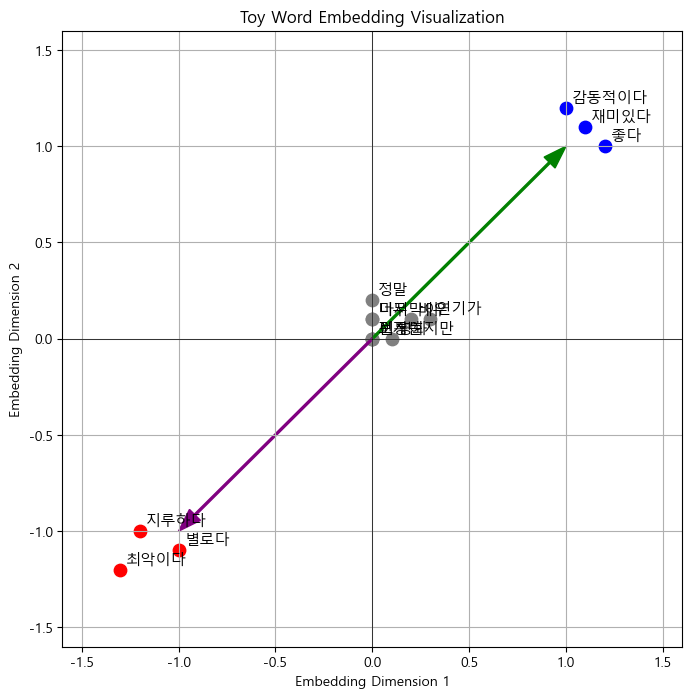

In [ ]:
import matplotlib.pyplot as plt


# -------------------------
# 한글 폰트 설정
# -------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


# -------------------------
# 시각화
# -------------------------



plt.figure(figsize=(8, 8))

for word, vec in toy_vocab.items():
    x, y = vec.tolist()

    # 색상 규칙
    if x > 0.5 and y > 0.5:
        color = 'blue'       # positive
    elif x < -0.5 and y < -0.5:
        color = 'red'        # negative
    else:
        color = 'gray'       # neutral

    plt.scatter(x, y, color=color, s=80)
    plt.text(x + 0.03, y + 0.03, word, fontsize=11)

# query 벡터 표시
plt.arrow(
    0, 0,
    poistive_query[0], poistive_query[1],
    color='green',
    width=0.01,
    head_width=0.08,
    length_includes_head=True,
    label='positive query'
)

plt.arrow(
    0, 0,
    negative_query[0], negative_query[1],
    color='purple',
    width=0.01,
    head_width=0.08,
    length_includes_head=True,
    label='negative query'
)

# 축
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.xlim(-1.6, 1.6)
plt.ylim(-1.6, 1.6)

plt.title("Toy Word Embedding Visualization")
plt.xlabel("Embedding Dimension 1")
plt.ylabel("Embedding Dimension 2")
plt.grid(True)


plt.show()

## 여러 문장 한 번에 비교

문장마다 어떤 단어에 attention이 많이 가는지 표로 비교한다.

In [ ]:
rows = []
for sentence in sentences:
    tokens = simple_tokenize(sentence)
    frame, context = attention_with_query(tokens, negative_query, toy_vocab)
    if len(frame) == 0:
        rows.append({
            'sentence': sentence,
            'top_token': None,
            'top_weight': None,
            'context_x': None,
            'context_y': None,
        })
        continue

    top_row = frame.sort_values('weight', ascending=False).iloc[0]
    rows.append({
        'sentence': sentence,
        'top_token': top_row['token'],
        'top_weight': round(float(top_row['weight']), 4),
        'context_x': round(float(context[0]), 4),
        'context_y': round(float(context[1]), 4),
    })

summary = pd.DataFrame(rows)
summary

,sentence,top_token,top_weight,context_x,context_y
0,이 영화 정말 좋다,이,0.3321,0.1151,0.1278
1,이 영화 너무 지루하다,지루하다,0.6233,-0.7357,-0.6110
2,배우 연기가 감동적이다,배우,0.4561,0.3377,0.2309
3,전개는 보통이지만 마지막이 재미있다,전개는,0.3182,0.0739,0.1035


# [8교시]

In [23]:
# 학습된 모델 대신 직접 생성한 embedding을 사용(toy-embedding)
import math
import re

import pandas as pd
import torch
import torch.nn.functional as F

torch.set_printoptions(precision=4, sci_mode=False)
pd.set_option('display.max_colwidth', None)

In [24]:
sentences = [
    '이 영화 정말 좋다',
    '이 영화 너무 지루하다',
    '배우 연기가 감동적이다',
    '전개는 보통이지만 마지막이 재미있다',
]

In [25]:
from pathlib import Path
from gensim.models import Word2Vec
import sys
import pandas as pd

# 프로젝트 루트 경로
project_root = Path('..').resolve()
sys.path.insert(0, str(project_root))

from preprocessing import preprocess_dataframe, build_vocab

# ===== Step 1: Daum 리뷰 데이터 로드 =====
# GitHub에서 직접 다운로드
DEFAULT_URL = "https://raw.githubusercontent.com/skn29teacher/skn29_lecture/main/data_nlp/daum_movie_review.csv"

print('Daum 리뷰 데이터 다운로드 중...')
try:
    df = pd.read_csv(DEFAULT_URL)
    print(f'다운로드 완료: {len(df)}개 샘플')
    print(f'컬럼: {list(df.columns)}')
except Exception as e:
    print(f'다운로드 실패: {e}')
    raise

# 컬럼 정규화
if "review" in df.columns:
    review_col = "review"
else:
    review_col = df.columns[0]

if "rating(1~10점)" in df.columns:
    rating_col = "rating(1~10점)"
elif "rating" in df.columns:
    rating_col = "rating"
else:
    rating_col = df.columns[1]

df = df[[review_col, rating_col]].copy()
df.columns = ["review", "rating"]

# 감정 레이블 생성
df["sentiment"] = (df["rating"] >= 6).astype(int)
train_df = df[["review", "sentiment"]].copy()
print(f'긍정: {(train_df["sentiment"]==1).sum()}, 부정: {(train_df["sentiment"]==0).sum()}')

# ===== Step 2: 전처리 및 tokenization =====
print('\n데이터 전처리 중...')
df_processed, vocab = preprocess_dataframe(
    train_df, 
    text_col='review', 
    label_col='sentiment',
    max_len=30,
    min_freq=2
)
word_to_idx = vocab
idx_to_word = {v: k for k, v in vocab.items()}
print(f'Vocab 크기: {len(vocab)}')

# ===== Step 3: Word2Vec 모델 학습 =====
print('\nWord2Vec 모델 학습 중... (1-2분 소요)')
tokenized_sentences = []
for tokens in df_processed['token_ids']:
    if len(tokens) > 0:
        words = [idx_to_word.get(idx, '<unk>') for idx in tokens if idx in idx_to_word]
        tokenized_sentences.append(words)

# Word2Vec 학습
w2v_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=5,
    seed=42
)
print(f'Word2Vec 모델 학습 완료 (vector_size={w2v_model.vector_size})')

# ===== Step 4: toy_vocab을 Word2Vec embedding으로 업데이트 =====
print('\ntoy_vocab을 Word2Vec embedding으로 업데이트 중...')

toy_vocab = {}
for word in vocab:
    if word in w2v_model.wv:
        toy_vocab[word] = torch.from_numpy(w2v_model.wv[word]).float()
    else:
        toy_vocab[word] = torch.zeros(w2v_model.vector_size).float()

print(f'{len(toy_vocab)}개 단어의 embedding 준비 완료')
print(f'embedding 차원: {w2v_model.vector_size}')
print('\n샘플 단어들 (처음 5개 차원):')

sample_words = ['좋다', '지루하다', '재미있다', '영화', '배우', '감동', '재미']
for word in sample_words:
    if word in toy_vocab:
        vec = toy_vocab[word][:5]
        print(f'{word}: {[round(v, 3) for v in vec.tolist()]}...')

# ===== Step 5: query를 100차원으로 업데이트 =====
positive_query = torch.ones(w2v_model.vector_size) * 0.1
negative_query = torch.ones(w2v_model.vector_size) * -0.1

print(f'\nQuery 벡터 업데이트 완료')
print(f'positive_query 크기: {positive_query.shape}')
print(f'negative_query 크기: {negative_query.shape}')
print(f'\n주의: toy_vocab은 이제 실제 Word2Vec embedding입니다.')


Daum 리뷰 데이터 다운로드 중...
다운로드 완료: 14725개 샘플
컬럼: ['review', 'rating', 'date', 'title']
긍정: 11179, 부정: 3546

데이터 전처리 중...
Vocab 크기: 14928

Word2Vec 모델 학습 중... (1-2분 소요)
Word2Vec 모델 학습 완료 (vector_size=100)

toy_vocab을 Word2Vec embedding으로 업데이트 중...
14928개 단어의 embedding 준비 완료
embedding 차원: 100

샘플 단어들 (처음 5개 차원):
좋다: [0.042, 0.095, 0.16, -0.175, -0.14]...
지루하다: [0.012, 0.031, 0.05, -0.044, -0.043]...
재미있다: [0.027, 0.048, 0.076, -0.088, -0.077]...
영화: [-0.091, 0.359, 0.556, -0.459, -0.29]...
배우: [0.065, 0.159, 0.279, -0.291, -0.237]...
감동: [0.043, 0.202, 0.362, -0.363, -0.287]...
재미: [0.04, 0.175, 0.314, -0.302, -0.24]...

Query 벡터 업데이트 완료
positive_query 크기: torch.Size([100])
negative_query 크기: torch.Size([100])

주의: toy_vocab은 이제 실제 Word2Vec embedding입니다.


In [26]:
# Removed 2D manual toy embeddings to avoid confusion.
# This notebook now uses the trained Word2Vec embeddings in `toy_vocab` exclusively.
toy_vocab_2d = None
toy_positive_query = None
toy_negative_query = None
print('2D toy embeddings removed. Use the trained Word2Vec `toy_vocab` by running the Word2Vec training cell if needed.')

2D toy embeddings removed. Use the trained Word2Vec `toy_vocab` by running the Word2Vec training cell if needed.


In [27]:
def simple_tokenize(text: str):
    text = re.sub(r'[^가-힣\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    if not text:
        return []
    return text.split()

def get_token_vectors(tokens, vocab):
    # Determine expected embedding dimension from vocab (if possible)
    dim = None
    try:
        for v in vocab.values():
            if hasattr(v, 'shape'):
                dim = v.shape[0]
                break
    except Exception:
        dim = None

    if dim is None:
        dim = 100

    vectors = []
    for token in tokens:
        vec = vocab.get(token, None)
        if vec is None:
            vectors.append(torch.zeros(dim))
        else:
            # ensure tensor and correct dim
            if not hasattr(vec, 'shape'):
                vec = torch.tensor(vec).float()
            if vec.shape[0] != dim:
                raise RuntimeError(f"Embedding dimension mismatch for token '{token}': {vec.shape[0]} vs expected {dim}")
            vectors.append(vec)

    return torch.stack(vectors) if vectors else torch.empty(0, dim)

def attention_with_query(tokens, query, vocab):
    """
    Attention 계산 함수.
    
    입력:
    - tokens: 문장을 토큰으로 나눈 리스트, 예: ['이', '영화', '정말', '좋다']
    - query: 지금 찾고 싶은 의미 벡터, 예: [1.0, 1.0] (positive)
    - vocab: 각 토큰의 embedding 벡터를 담은 딕셔너리
    
    출력:
    - frame: 각 토큰의 key, score, weight, value를 담은 DataFrame
    - context: query와 문장의 attention 결과로 만든 요약 벡터
    """
    
    # ===== Step 1: 각 토큰을 벡터로 바꾼다 =====
    # tokens를 vocab에서 찾아서 벡터로 변환한다.
    # 예: '좋다' -> [1.2, 1.0, ...] (100차원)
    key = get_token_vectors(tokens, vocab)
    
    # 간단한 예제에서는 key와 value를 같게 둔다.
    # (실제 모델에서는 key와 value를 만드는 다른 layer가 있다)
    value = key
    
    # 토큰이 없으면 빈 결과를 반환한다
    if key.numel() == 0:
        return pd.DataFrame(), torch.tensor([])
    
    # ===== Step 2: query와 key의 유사도를 계산한다 (score) =====
    # score = query · key / sqrt(d_k)
    # dot product는 두 벡터가 같은 방향일수록 크다.
    d_k = key.size(-1)  # embedding 차원
    scores = torch.matmul(key, query) / math.sqrt(d_k)
    # scores shape: [토큰 개수]
    
    # ===== Step 3: score를 확률처럼 바꾼다 (weight) =====
    # softmax를 사용해서 score들을 0~1 사이의 값으로 정규화한다.
    # 모든 weight의 합은 1이 된다.
    # score가 높을수록 weight도 크다.
    weights = F.softmax(scores, dim=0)
    # weights shape: [토큰 개수]
    
    # ===== Step 4: weight를 이용해서 value들을 섞는다 (context) =====
    # context = sum(weight_i * value_i)
    # 이것이 attention의 핵심이다.
    # weight가 높은 토큰의 value가 더 많이 더해진다.
    context = torch.sum(weights.unsqueeze(-1) * value, dim=0)
    # context shape: [embedding 차원]
    
    # ===== 결과를 DataFrame으로 정리한다 =====
    # 각 토큰에 대해 score, weight를 표로 만든다
    # (100차원 embedding은 표로 출력하기 어려우므로 요약만 함)
    frame = pd.DataFrame({
        'token': tokens,
        'score': scores.tolist(),
        'weight': weights.tolist(),
    })
    
    return frame, context

In [28]:
sentence = sentences[0]
tokens = simple_tokenize(sentence)

# 강제: 항상 100차원 Word2Vec(`toy_vocab`) 사용
if 'toy_vocab' not in globals() or not toy_vocab:
    raise RuntimeError("Word2Vec 임베딩이 없습니다. 먼저 '2-1. 실제 Word2Vec Embedding 학습하기' 셀을 실행하세요.")

# 학습된 쿼리가 있으면 우선 사용, 없으면 기본 positive_query 사용
if 'learned_positive_query' in globals():
    query_to_use = learned_positive_query
elif 'positive_query' in globals():
    query_to_use = positive_query
else:
    # 안전장치: toy_vocab의 차원에 맞춰 기본 쿼리 생성
    first_vec = next(iter(toy_vocab.values()))
    query_to_use = torch.ones(first_vec.shape[0]) * 0.1

frame, context = attention_with_query(tokens, query_to_use, toy_vocab)

print('sentence:', sentence)
print('tokens:', tokens)
print('using_vocab: toy_vocab (Word2Vec)')
print('query_shape:', list(query_to_use.shape))
print('context:', context.tolist())
display(frame.sort_values('weight', ascending=False).reset_index(drop=True))

sentence: 이 영화 정말 좋다
tokens: ['이', '영화', '정말', '좋다']
using_vocab: toy_vocab (Word2Vec)
query_shape: [100]
context: [-0.012336843647062778, 0.1136513203382492, 0.1791720986366272, -0.15846598148345947, -0.1075621098279953, 0.43906956911087036, -0.18548840284347534, 0.27736493945121765, -0.1556999832391739, -0.3377522826194763, -0.033252641558647156, 0.2769632935523987, -0.17898212373256683, 0.2452690601348877, 0.1841171830892563, -0.14935457706451416, -0.13713222742080688, -0.5034841299057007, -0.04063129797577858, -0.1612686663866043, 0.015023157000541687, 0.30301767587661743, 0.007171976380050182, 0.8049991130828857, 0.19210445880889893, 0.4387732148170471, -0.48635008931159973, 0.05521422624588013, -0.1853906363248825, -0.15695443749427795, -0.1507650762796402, -0.18678978085517883, -0.20409998297691345, 0.02587549015879631, 0.39385688304901123, -0.08235742151737213, 0.1696770340204239, -0.06746280193328857, -0.3313048183917999, 0.2947424054145813, 0.15854734182357788, 0.078561082482

,token,score,weight
0,영화,0.000681,0.250234
1,이,0.000000,0.250064
2,정말,0.000000,0.250064
3,좋다,-0.001700,0.249639


In [29]:
# 긍정 리뷰와 부정 리뷰의 embedding 평균을 계산
print('데이터에서 긍정/부정 query 추출 중...')

positive_indices = (train_df['sentiment'] == 1).values
negative_indices = (train_df['sentiment'] == 0).values

# 각 리뷰의 토큰 embedding의 평균을 구한다
positive_vecs = []
negative_vecs = []

for idx, token_ids in enumerate(df_processed['token_ids']):
    if len(token_ids) == 0:
        continue
    
    # 토큰 embedding 평균
    vecs = [toy_vocab.get(idx_to_word.get(tid, '<unk>'), torch.zeros(100)) for tid in token_ids if tid in idx_to_word]
    if vecs:
        avg_vec = torch.stack(vecs).mean(dim=0)
        if train_df.iloc[idx]['sentiment'] == 1:
            positive_vecs.append(avg_vec)
        else:
            negative_vecs.append(avg_vec)

# 긍정/부정 쿼리 계산
learned_positive_query = torch.stack(positive_vecs[:1000]).mean(dim=0) if positive_vecs else torch.zeros(100)
learned_negative_query = torch.stack(negative_vecs[:1000]).mean(dim=0) if negative_vecs else torch.zeros(100)

print(f'긍정 query 샘플: {learned_positive_query[:5].tolist()}...')
print(f'부정 query 샘플: {learned_negative_query[:5].tolist()}...')


데이터에서 긍정/부정 query 추출 중...
긍정 query 샘플: [-0.04626259580254555, 0.1855328530073166, 0.26360583305358887, -0.2356732189655304, -0.1709718555212021]...
부정 query 샘플: [-0.05166228488087654, 0.1915784329175949, 0.2704726457595825, -0.23931938409805298, -0.1732930988073349]...


In [30]:
sentence = sentences[0]
tokens = simple_tokenize(sentence)

# 강제: 항상 100차원 Word2Vec(`toy_vocab`) 사용
if 'toy_vocab' not in globals() or not toy_vocab:
    raise RuntimeError("Word2Vec 임베딩이 없습니다. 먼저 '2-1. 실제 Word2Vec Embedding 학습하기' 셀을 실행하세요.")

# 학습된 쿼리가 있으면 우선 사용, 없으면 기본 positive_query 사용
if 'learned_positive_query' in globals():
    query_to_use = learned_positive_query
elif 'positive_query' in globals():
    query_to_use = positive_query
else:
    # 안전장치: toy_vocab의 차원에 맞춰 기본 쿼리 생성
    first_vec = next(iter(toy_vocab.values()))
    query_to_use = torch.ones(first_vec.shape[0]) * 0.1

frame, context = attention_with_query(tokens, query_to_use, toy_vocab)

print('sentence:', sentence)
print('tokens:', tokens)
print('using_vocab: toy_vocab (Word2Vec)')
print('query_shape:', list(query_to_use.shape))
print('context:', context.tolist())
display(frame.sort_values('weight', ascending=False).reset_index(drop=True))

sentence: 이 영화 정말 좋다
tokens: ['이', '영화', '정말', '좋다']
using_vocab: toy_vocab (Word2Vec)
query_shape: [100]
context: [-0.06780771911144257, 0.2996649742126465, 0.46594977378845215, -0.38926297426223755, -0.24959012866020203, 1.0755614042282104, -0.5078930854797363, 0.6836657524108887, -0.4320087432861328, -0.8576511144638062, -0.06085730344057083, 0.7144497632980347, -0.42763689160346985, 0.5736747980117798, 0.47524550557136536, -0.32609823346138, -0.36653873324394226, -1.2362658977508545, -0.08743523806333542, -0.41459202766418457, 0.024239111691713333, 0.6966136693954468, 0.0147319957613945, 1.92428457736969, 0.5121340751647949, 1.0843693017959595, -1.1863850355148315, 0.11053873598575592, -0.454505980014801, -0.39452001452445984, -0.3975019156932831, -0.4818243980407715, -0.5114720463752747, 0.07412118464708328, 0.9791074395179749, -0.19822591543197632, 0.44056808948516846, -0.12173879146575928, -0.8314547538757324, 0.7277500033378601, 0.37460753321647644, 0.20465275645256042, 0.64791

,token,score,weight
0,영화,3.058150,0.802158
1,좋다,1.178791,0.122480
2,이,0.000000,0.037681
3,정말,0.000000,0.037681


In [31]:
test_sentence = '이 영화 정말 좋다'
tokens = simple_tokenize(test_sentence)

pos_frame, pos_context = attention_with_query(tokens, learned_positive_query, toy_vocab)
neg_frame, neg_context = attention_with_query(tokens, learned_negative_query, toy_vocab)

print(f'문장: {test_sentence}')
print(f'토큰: {tokens}')
print()
print('[긍정 query 사용]')
display(pos_frame.sort_values('weight', ascending=False).reset_index(drop=True))

print('\n[부정 query 사용]')
display(neg_frame.sort_values('weight', ascending=False).reset_index(drop=True))


문장: 이 영화 정말 좋다
토큰: ['이', '영화', '정말', '좋다']

[긍정 query 사용]


,token,score,weight
0,영화,3.058150,0.802158
1,좋다,1.178791,0.122480
2,이,0.000000,0.037681
3,정말,0.000000,0.037681



[부정 query 사용]


,token,score,weight
0,영화,3.103167,0.807686
1,좋다,1.194593,0.119773
2,이,0.000000,0.036271
3,정말,0.000000,0.036271


In [32]:
compare_sentence = '이 영화 정말 좋다 하지만 마지막이 별로다'
tokens = simple_tokenize(compare_sentence)

# 강제: 항상 100차원 Word2Vec(`toy_vocab`) 사용
if 'toy_vocab' not in globals() or not toy_vocab:
    raise RuntimeError("Word2Vec 임베딩이 없습니다. 먼저 '2-1. 실제 Word2Vec Embedding 학습하기' 셀을 실행하세요.")

# 학습된 쿼리가 있으면 우선 사용, 없으면 기본 쿼리 사용
pos_q = learned_positive_query if 'learned_positive_query' in globals() else (positive_query if 'positive_query' in globals() else None)
neg_q = learned_negative_query if 'learned_negative_query' in globals() else (negative_query if 'negative_query' in globals() else None)

if pos_q is None or neg_q is None:
    # 안전장치: toy_vocab 차원에 맞추어 기본값 생성
    dim = next(iter(toy_vocab.values())).shape[0]
    if pos_q is None:
        pos_q = torch.ones(dim) * 0.1
    if neg_q is None:
        neg_q = torch.ones(dim) * -0.1

pos_frame, pos_context = attention_with_query(tokens, pos_q, toy_vocab)
neg_frame, neg_context = attention_with_query(tokens, neg_q, toy_vocab)

print('sentence:', compare_sentence)
print('tokens:', tokens)
print()
print('[positive query]')
print('query_shape:', list(pos_q.shape))
print('context:', pos_context.tolist())
display(pos_frame.sort_values('weight', ascending=False).reset_index(drop=True))

print('[negative query]')
print('query_shape:', list(neg_q.shape))
print('context:', neg_context.tolist())
display(neg_frame.sort_values('weight', ascending=False).reset_index(drop=True))

sentence: 이 영화 정말 좋다 하지만 마지막이 별로다
tokens: ['이', '영화', '정말', '좋다', '하지만', '마지막이', '별로다']

[positive query]
query_shape: [100]
context: [-0.05585084855556488, 0.2622016668319702, 0.4091571271419525, -0.34425246715545654, -0.22128096222877502, 0.9482914209365845, -0.44247111678123474, 0.6033657193183899, -0.3750779926776886, -0.7542526721954346, -0.056409962475299835, 0.6257213950157166, -0.3785029649734497, 0.508912980556488, 0.416944682598114, -0.2911548614501953, -0.32070180773735046, -1.0900804996490479, -0.07861381769180298, -0.36318692564964294, 0.022579839453101158, 0.6196568608283997, 0.013826909475028515, 1.702789306640625, 0.44802626967430115, 0.9559745788574219, -1.0471584796905518, 0.10067510604858398, -0.4008624851703644, -0.3460933268070221, -0.3479090631008148, -0.4226929545402527, -0.4499259293079376, 0.064238540828228, 0.8626547455787659, -0.17477701604366302, 0.38628652691841125, -0.11263015121221542, -0.7307387590408325, 0.6409741044044495, 0.332327276468277, 0.17886985

,token,score,weight
0,영화,3.058150,0.692060
1,좋다,1.178791,0.105669
2,마지막이,0.566841,0.057304
3,별로다,0.377928,0.047439
4,이,0.000000,0.032509
5,정말,0.000000,0.032509
6,하지만,0.000000,0.032509


[negative query]
query_shape: [100]
context: [-0.05671856924891472, 0.26476871967315674, 0.4130735397338867, -0.3473321795463562, -0.22315405309200287, 0.9568595290184021, -0.44697675108909607, 0.608820915222168, -0.3789753317832947, -0.7613155841827393, -0.05669834092259407, 0.6317386031150818, -0.3818069398403168, 0.5132394433021545, 0.420928955078125, -0.2934187352657318, -0.323870450258255, -1.09994375705719, -0.07919827103614807, -0.36666804552078247, 0.022666223347187042, 0.624789834022522, 0.013905705884099007, 1.7176693677902222, 0.4524468779563904, 0.9646721482276917, -1.0565497875213623, 0.10132411867380142, -0.40448197722435, -0.34934234619140625, -0.35131168365478516, -0.4267312288284302, -0.45409685373306274, 0.06492160260677338, 0.870555579662323, -0.17633524537086487, 0.3900017738342285, -0.11320015788078308, -0.7375432252883911, 0.6468231081962585, 0.3351748287677765, 0.1806151419878006, 0.5764188170433044, -0.38193100690841675, -0.30660468339920044, 0.7534661889076233,

,token,score,weight
0,영화,3.103167,0.699981
1,좋다,1.194593,0.103801
2,마지막이,0.574172,0.055816
3,별로다,0.382944,0.046101
4,이,0.000000,0.031434
5,정말,0.000000,0.031434
6,하지만,0.000000,0.031434


In [33]:
rows = []
for sentence in sentences:
    tokens = simple_tokenize(sentence)
    frame, context = attention_with_query(tokens, positive_query, toy_vocab)
    if len(frame) == 0:
        rows.append({
            'sentence': sentence,
            'top_token': None,
            'top_weight': None,
            'context_x': None,
            'context_y': None,
        })
        continue

    top_row = frame.sort_values('weight', ascending=False).iloc[0]
    rows.append({
        'sentence': sentence,
        'top_token': top_row['token'],
        'top_weight': round(float(top_row['weight']), 4),
        'context_x': round(float(context[0]), 4),
        'context_y': round(float(context[1]), 4),
    })

summary = pd.DataFrame(rows)
summary

,sentence,top_token,top_weight,context_x,context_y
0,이 영화 정말 좋다,영화,0.2502,-0.0123,0.1137
1,이 영화 너무 지루하다,영화,0.2502,-0.0196,0.0975
2,배우 연기가 감동적이다,감동적이다,0.3339,0.0436,0.1356
3,전개는 보통이지만 마지막이 재미있다,보통이지만,0.2502,0.0162,0.0289
